In [2]:
!git clone https://github.com/jnheinrich451-eng/MultiDrone.git

Cloning into 'MultiDrone'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 57 (delta 16), reused 19 (delta 7), pack-reused 28 (from 1)
Receiving objects: 100% (57/57), 46.53 KiB | 2.74 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [13]:
!git pull

remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 17 (delta 12), reused 17 (delta 12), pack-reused 0 (from 0)
Unpacking objects: 100% (17/17), 9.15 KiB | 1.31 MiB/s, done.
From https://github.com/jnheinrich451-eng/MultiDrone
   9c1d384..a553d32  main       -> origin/main
Updating 9c1d384..a553d32
Fast-forward
 envs/clutter_n000.yaml |  31 +++++
 envs/clutter_n005.yaml |  57 +++++++++
 envs/clutter_n010.yaml |  88 ++++++++++++++
 envs/clutter_n020.yaml | 133 +++++++++++++++++++++
 envs/clutter_n030.yaml | 184 +++++++++++++++++++++++++++++
 envs/clutter_n040.yaml | 233 +++++++++++++++++++++++++++++++++++++
 envs/passage_w010.yaml |  69 +++++++++++
 envs/passage_w015.yaml |  69 +++++++++++
 envs/passage_w020.yaml |  69 +++++++++++
 envs/passage_w030.yaml |  69 +++++++++++
 envs/passage_w040.yaml |  69 +++++++++++
 envs/passage_w050.yaml |  69 +++++++++++
 envs/passage_w060.yaml |  69 ++++++++++

In [6]:
%cd MultiDrone/

/content/MultiDrone


In [8]:
!pip install python-fcl vedo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.1 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 93.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 MB 7.0 MB/s eta 0:00:00:00:0100:01
  Created wheel for vedo: filename=vedo-2026.6.1-py3-none-any.whl size=2823123 sha256=d35e4d0483f6361b7bbe3c705ab93eae39d4033eee46e03f74bbe84078a587be
  Stored in directory: /root/.cache/pip/wheels/a6/87/43/56603acbb1373aa7463afd2561478d00a6d5bb3aa40403938b
Successfully built vedo


In [7]:
!python rrt_connect.py --env envs/passage_w010.yaml --drones 5 --runs 30 --no-smooth 

run   1/30: solved  search=  0.61s  nodes=   260 (start 163, goal 97)  len=  611.76
run   2/30: solved  search=  0.86s  nodes=   371 (start 206, goal 165)  len=  704.62
run   3/30: solved  search=  0.97s  nodes=   522 (start 221, goal 301)  len=  740.06
run   4/30: solved  search=  3.60s  nodes=  1621 (start 859, goal 762)  len=  809.79
run   5/30: solved  search=  2.19s  nodes=   971 (start 537, goal 434)  len=  811.76
run   6/30: solved  search=  3.66s  nodes=  1617 (start 898, goal 719)  len=  860.30
run   7/30: solved  search=  9.95s  nodes=  4213 (start 2094, goal 2119)  len=  809.32
run   8/30: solved  search=  0.24s  nodes=   113 (start 60, goal 53)  len=  538.88
run   9/30: solved  search=  0.94s  nodes=   418 (start 203, goal 215)  len=  592.02
run  10/30: solved  search=  0.32s  nodes=   148 (start 86, goal 62)  len=  591.64
run  11/30: solved  search=  2.02s  nodes=   870 (start 478, goal 392)  len=  701.09
run  12/30: solved  search=  4.65s  nodes=  1948 (start 1105, goal 8

RRT          19/20  mean=6.26s
RRT-Connect  20/20  mean=0.71s


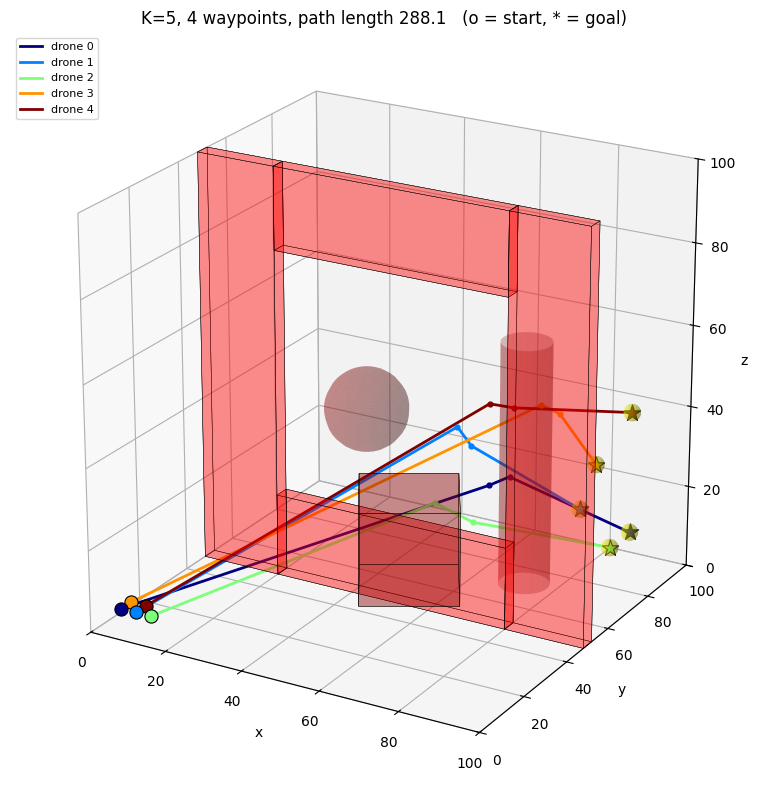

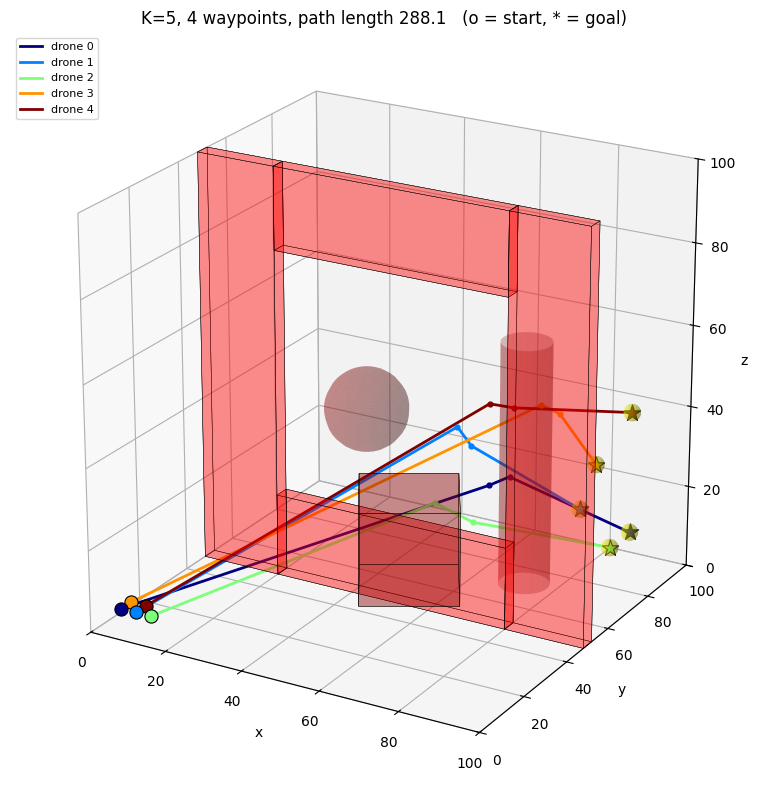

In [11]:
from multi_drone import MultiDrone
from rrt_planner import rrt_plan
from rrt_connect import rrt_connect_plan
from plot_path import plot_path
import numpy as np

sim = MultiDrone(num_drones=5, environment_file="env_0.yaml")
for name, fn in [("RRT", rrt_plan), ("RRT-Connect", rrt_connect_plan)]:
    ok, ts = 0, []
    for seed in range(20):
        path, s = fn(sim, time_limit=20.0, seed=seed, smooth=False)
        if s["success"]:
            ok += 1; ts.append(s["search_time"])
    print(f"{name:12s} {ok:2d}/20  mean={np.mean(ts) if ts else float('nan'):.2f}s")

path, _ = rrt_connect_plan(sim, time_limit=20.0, seed=0)
fig, ax = plot_path(path, "env_0.yaml", out=None); fig


solved=True  search=1.57s  waypoints=5


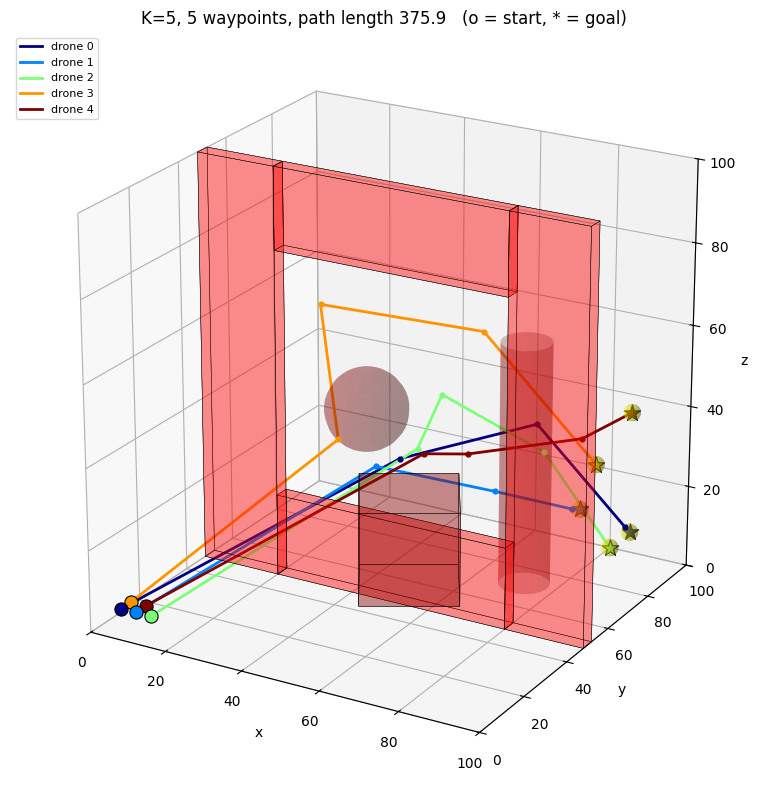

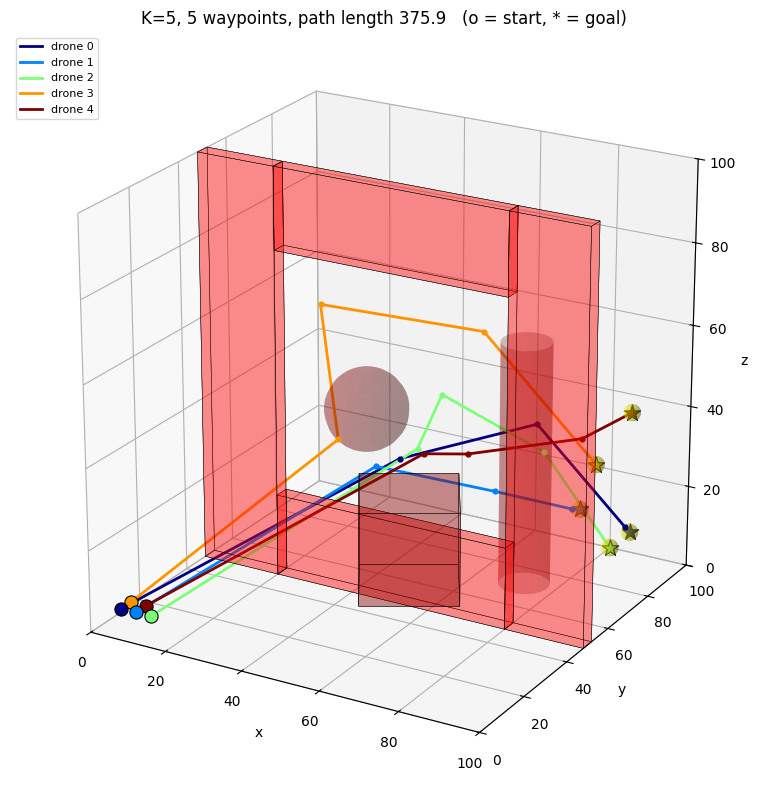

In [10]:
%matplotlib inline
from multi_drone import MultiDrone
from rrt_planner import rrt_plan
from plot_path import plot_path, plot_drone_separation

sim = MultiDrone(num_drones=5, environment_file="env_0.yaml")
path, stats = rrt_plan(sim, time_limit=20.0, seed=0)
print(f"solved={stats['success']}  search={stats['search_time']:.2f}s  "
      f"waypoints={len(path)}")

fig, ax = plot_path(path, "env_0.yaml", out=None)
fig                     # last expression in the cell -> renders inline